In [1]:
# Import
import shutil
import torch
import tempfile
from pathlib import Path
from mrpro.data import KData  # Import the KData class
from mrpro.data.traj_calculators import KTrajectoryPulseq, KTrajectoryIsmrmrd
from mrpro.data.SpatialDimension import SpatialDimension
import matplotlib.pyplot as plt
import requests
import mrpro
import nibabel as nib
import numpy as np

# Local path
h5_path_cartesian = '/data/bouill01/goooo/20240801_cartesian_2D_256mm_256Nx_256Ny_15alpha/meas_MID00128_FID07024_20240801_cartesian_2D_256mm_256Nx_256Ny_15alpha.h5'
seq_path_cartesian = '/data/bouill01/goooo/20240801_cartesian_2D_256mm_256Nx_256Ny_15alpha/20240801_cartesian_2D_256mm_256Nx_256Ny_15alpha.seq'

h5_path_radial_uni = '/data/bouill01/goooo/20240801_radial_2D_new_256mm_200spokes_uniform/meas_MID00126_FID07022_20240801_radial_2D_new_256mm_200spokes_uniform_with_traj.h5'
seq_path_radial_uni = '/data/bouill01/goooo/20240801_radial_2D_new_256mm_200spokes_uniform/20240801_radial_2D_new_256mm_200spokes_uniform.seq'

h5_path_radial_gold = '/data/bouill01/goooo/20240801_radial_2D_new_256mm_200spokes_golden_angle/meas_MID00127_FID07023_20240801_radial_2D_new_256mm_200spokes_golden_angle_with_traj.h5'
seq_path_radial_gold = '/data/bouill01/goooo/20240801_radial_2D_new_256mm_200spokes_golden_angle/20240801_radial_2D_new_256mm_200spokes_golden_angle.seq'

h5_path_spiral = '/data/bouill01/goooo/20240801_spiral_2D_256mm_472k0_32interleaves_golden_angle_vds/meas_MID00125_FID07021_20240801_spiral_2D_256mm_472k0_32interleaves_golden_angle_vds_with_traj.h5'
seq_path_spiral = '/data/bouill01/goooo/20240801_spiral_2D_256mm_472k0_32interleaves_golden_angle_vds/20240801_spiral_2D_256mm_472k0_32interleaves_golden_angle_vds.seq'

h5_path_test ='/data/bouill01/PTBSequences/PTBSequences/30july/2dn3d/3D/20240730_spiral_interleaved_3D_256mm_924k0_16interleaves_golden_angle_[0.256, -0.192]fov_scaling_3D/meas_MID00042_FID06818_20240730_spiral_interleaved_3D_256mm_924k0_16interleaves_with_traj.h5'

h5_path_new = '/data/bouill01/PTBSequences/PTBSequences/30july/20240730_spiral_2D_256mm_3656k0_4interleaves_golden_angle_vds/meas_MID00078_FID06852_20240730_spiral_2D_256mm_3656k0_4interleaves_golden_angle_vds_with_traj.h5'

### CArt

In [2]:
import matplotlib.pyplot as plt
import torch

# Load data from ISMRMRD file using KTrajectoryIsmrmrd
kdatapuls = KData.from_file(h5_path_cartesian, KTrajectoryPulseq(seq_path=seq_path_cartesian))
kdatapuls.header.recon_matrix = SpatialDimension(z=1, y=256, x=256)

# Perform the reconstruction
reconstructionpuls = mrpro.algorithms.reconstruction.DirectReconstruction.from_kdata(kdatapuls)
# Use this to run on GPU: kdata = kdata.cuda()
img = reconstructionpuls(kdatapuls)

# Display the reconstructed image
# If there are multiple slices, only the first one is selected
first_img = img.rss().cpu()[0, 0, :, :]  # images, z, y, x

# Create a figure with three subplots: one for all trajectories, one for every 10th kx, and one for the image
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
fig.suptitle('Cartesian K-space and Reconstruction')

# Plot all k-space trajectories
ax1 = axes[0]
# Create grid
kx_grid, ky_grid = torch.meshgrid(torch.arange(256), torch.arange(256))

# Flatten and plot all k-space trajectories
ax1.plot(ky_grid.flatten().numpy(), kx_grid.flatten().numpy(), 'o', alpha=0.5)
ax1.set_xlabel('ky')
ax1.set_ylabel('kx')
ax1.set_title('All K-space Trajectories')

# Plot k-space trajectories with every 10th point in kx
ax2 = axes[1]
# Sample every 10th point in kx dimension, keeping all ky points
sample_rate_kx = 10
kx_sampled = kx_grid[::sample_rate_kx, :]
ky_sampled = ky_grid[::sample_rate_kx, :]

# Flatten and plot
ax2.plot(ky_sampled.flatten().numpy(), kx_sampled.flatten().numpy(), 'o', alpha=0.5)
ax2.set_xlabel('ky')
ax2.set_ylabel('kx')
ax2.set_title('Every 10th Kx Point')

# Plot the reconstructed image
ax3 = axes[2]
ax3.matshow(first_img, cmap='gray')
ax3.set_title('Reconstructed Image')

# Display the combined figure
plt.show()


AttributeError: 'AdjointLinearOperator' object has no attribute '_operator2'

In [ ]:
kdatapuls.data.shape

torch.Size([1, 10, 1, 256, 256])

### Rad Uni

In [ ]:
# Load data from ISMRMRD file using KTrajectoryIsmrmrd
kdata_ismrmrd = KData.from_file(h5_path_radial_uni, KTrajectoryIsmrmrd())
# kdata_ismrmrd.header.recon_matrix = SpatialDimension(z=1, y=256, x=256)
# kdata_ismrmrd.header.encoding_matrix = SpatialDimension(z=1, y=256, x=256)

# Perform the reconstruction
reconstruction_ismrmrd = mrpro.algorithms.reconstruction.IterativeSenseReconstruction.from_kdata(kdata_ismrmrd, n_max_iter=10)
img = reconstruction_ismrmrd(kdata_ismrmrd)

# Display the reconstructed image
# If there are multiple slices, only the first one is selected
first_img = torch.abs(img.data[0, 0, 0, :, :])  # images, z, y, x

# Define values to compare for us_idx
us_idx_values = [torch.arange(0, 200, 40)[None, :]]

# Create a figure with three subplots: one for a single trajectory, one for all trajectories, and one for the image
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
fig.suptitle('ADC = 472, 32 interleaves, 15 104 total points')
# Plot a single k-space trajectory for the first us_idx value on the first subplot
ax1 = axes[0]
single_us_idx = us_idx_values[0]
print(f"Calculating for single us_idx:", single_us_idx)

# Split k-space data into other dimensions based on undersampling indices
kdata_us_single = KData.split_k1_into_other(kdata_ismrmrd, single_us_idx, other_label='repetition')

# Plot single k-space trajectory for ISMRMRD
ax1.plot(kdata_us_single.traj.ky.flatten(), kdata_us_single.traj.kx.flatten(), 'o', label='Single us_idx - ISMRMRD')
ax1.set_xlabel('ky')
ax1.set_ylabel('kx')
ax1.set_title('Single K-space Trajectory')
ax1.legend()

# Plot k-space trajectories for all us_idx values on the second subplot
ax2 = axes[1]
# Plot k-space trajectory for ISMRMRD
ax2.plot(kdata_ismrmrd.traj.ky.flatten(), kdata_ismrmrd.traj.kx.flatten(), 'o')

ax2.set_xlabel('ky')
ax2.set_ylabel('kx')
ax2.set_title('All K-space Trajectories')
ax2.legend()

# Plot the reconstructed image on the third subplot
ax3 = axes[2]
ax3.matshow(first_img, cmap='gray')
ax3.set_title('Reconstructed Image')

# Display the combined figure
plt.show()

AttributeError: 'AdjointLinearOperator' object has no attribute '_operator2'

In [ ]:
kdata_ismrmrd.data.shape

torch.Size([1, 10, 1, 200, 256])

### Rad Gold

Calculating for single us_idx: tensor([[  0,  40,  80, 120, 160]])


/tmp/ipykernel_22403/1458120381.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


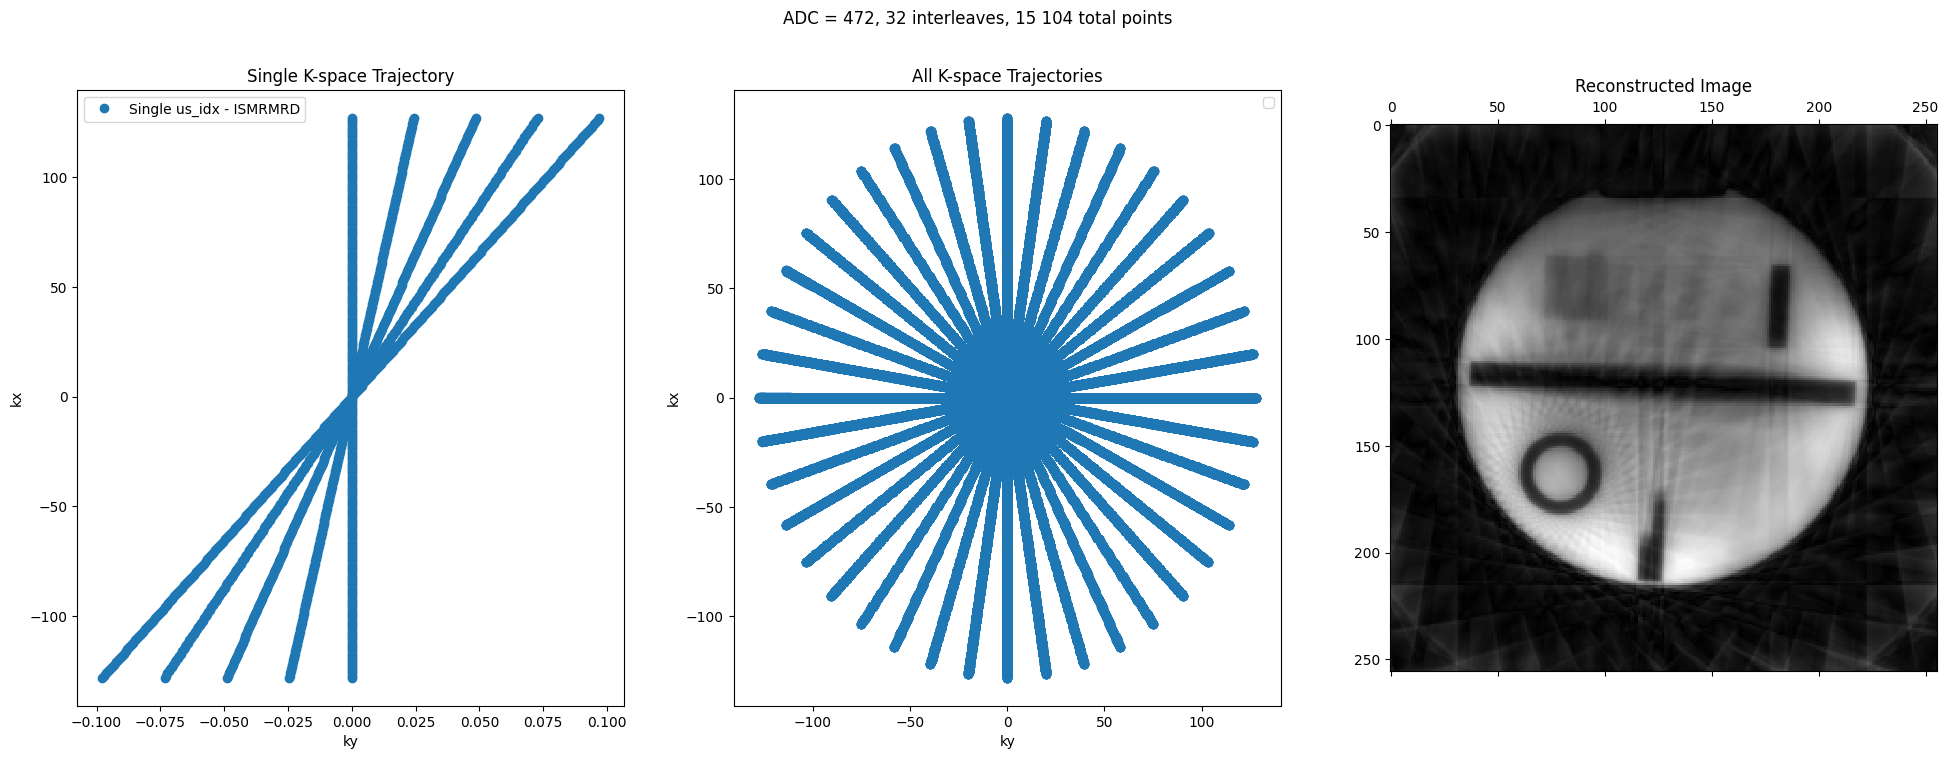

In [ ]:
# Load data from ISMRMRD file using KTrajectoryIsmrmrd
kdata_ismrmrd = KData.from_file(h5_path_radial_gold, KTrajectoryIsmrmrd())
# kdata_ismrmrd.header.recon_matrix = SpatialDimension(z=1, y=256, x=256)
# kdata_ismrmrd.header.encoding_matrix = SpatialDimension(z=1, y=256, x=256)

# Perform the reconstruction
reconstruction_ismrmrd = mrpro.algorithms.reconstruction.IterativeSenseReconstruction.from_kdata(kdata_ismrmrd, n_max_iter=10)
img = reconstruction_ismrmrd(kdata_ismrmrd)

# Display the reconstructed image
# If there are multiple slices, only the first one is selected
first_img = torch.abs(img.data[0, 0, 0, :, :])  # images, z, y, x

# Define values to compare for us_idx
us_idx_values = [torch.arange(0, 200, 40)[None, :]]

# Create a figure with three subplots: one for a single trajectory, one for all trajectories, and one for the image
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
fig.suptitle('ADC = 472, 32 interleaves, 15 104 total points')
# Plot a single k-space trajectory for the first us_idx value on the first subplot
ax1 = axes[0]
single_us_idx = us_idx_values[0]
print(f"Calculating for single us_idx:", single_us_idx)

# Split k-space data into other dimensions based on undersampling indices
kdata_us_single = KData.split_k1_into_other(kdata_ismrmrd, single_us_idx, other_label='repetition')

# Plot single k-space trajectory for ISMRMRD
ax1.plot(kdata_us_single.traj.ky.flatten(), kdata_us_single.traj.kx.flatten(), 'o', label='Single us_idx - ISMRMRD')
ax1.set_xlabel('ky')
ax1.set_ylabel('kx')
ax1.set_title('Single K-space Trajectory')
ax1.legend()

# Plot k-space trajectories for all us_idx values on the second subplot
ax2 = axes[1]
# Plot k-space trajectory for ISMRMRD
ax2.plot(kdata_ismrmrd.traj.ky.flatten(), kdata_ismrmrd.traj.kx.flatten(), 'o')

ax2.set_xlabel('ky')
ax2.set_ylabel('kx')
ax2.set_title('All K-space Trajectories')
ax2.legend()

# Plot the reconstructed image on the third subplot
ax3 = axes[2]
ax3.matshow(first_img, cmap='gray')
ax3.set_title('Reconstructed Image')

# Display the combined figure
plt.show()

In [ ]:
kdata_ismrmrd.data.shape

torch.Size([1, 10, 1, 200, 256])

### Spirals

Calculating for single us_idx: tensor([[0]])


/tmp/ipykernel_22403/2780225144.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


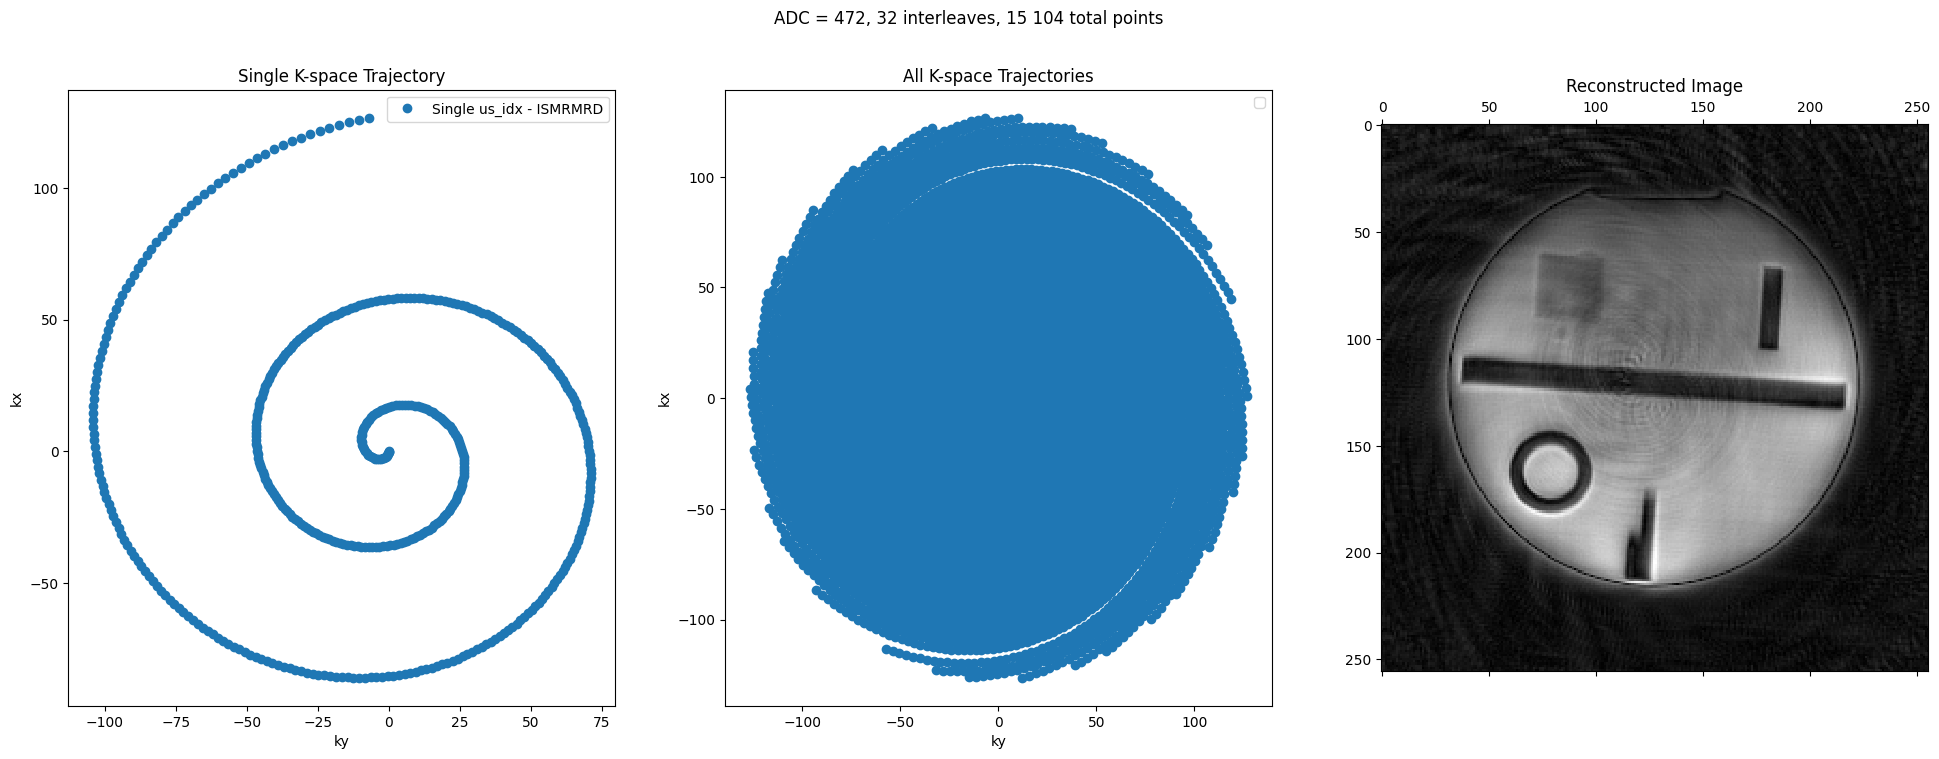

In [ ]:
# Load data from ISMRMRD file using KTrajectoryIsmrmrd
kdata_ismrmrd = KData.from_file(h5_path_spiral, KTrajectoryIsmrmrd())

# Perform the reconstruction
reconstruction_ismrmrd = mrpro.algorithms.reconstruction.DirectReconstruction.from_kdata(kdata_ismrmrd)
img = reconstruction_ismrmrd(kdata_ismrmrd)

# Display the reconstructed image
# If there are multiple slices, only the first one is selected
first_img = img.rss().cpu()[0, 0, :, :]  # images, z, y, x

# Define values to compare for us_idx
us_idx_values = [torch.arange(0, 8, 139)[None, :]]

# Create a figure with three subplots: one for a single trajectory, one for all trajectories, and one for the image
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
fig.suptitle('ADC = 472, 32 interleaves, 15 104 total points')
# Plot a single k-space trajectory for the first us_idx value on the first subplot
ax1 = axes[0]
single_us_idx = us_idx_values[0]
print(f"Calculating for single us_idx:", single_us_idx)

# Split k-space data into other dimensions based on undersampling indices
kdata_us_single = kdata_ismrmrd.split_k1_into_other(single_us_idx, other_label='repetition')

# Plot single k-space trajectory for ISMRMRD
ax1.plot(kdata_us_single.traj.ky.flatten(), kdata_us_single.traj.kx.flatten(), 'o', label='Single us_idx - ISMRMRD')
ax1.set_xlabel('ky')
ax1.set_ylabel('kx')
ax1.set_title('Single K-space Trajectory')
ax1.legend()

# Plot k-space trajectories for all us_idx values on the second subplot
ax2 = axes[1]
# Plot k-space trajectory for ISMRMRD
ax2.plot(kdata_ismrmrd.traj.ky.flatten(), kdata_ismrmrd.traj.kx.flatten(), 'o')

ax2.set_xlabel('ky')
ax2.set_ylabel('kx')
ax2.set_title('All K-space Trajectories')
ax2.legend()

# Plot the reconstructed image on the third subplot
ax3 = axes[2]
ax3.matshow(first_img, cmap='gray')
ax3.set_title('Reconstructed Image')

# Display the combined figure
plt.show()

In [ ]:
kdata_ismrmrd.data.shape

torch.Size([1, 10, 1, 32, 472])